# Scikit learn's linear regression + custom analytical solution

### Libraries and constants

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold

In [2]:
# --- CONSTANTS ---
RANDOM_SEED = 42
TARGET_NAME = 'price'

### Data import

In [3]:
df_train = pd.read_csv(Path('data') / '3 train_post_EDA.csv')
df_test = pd.read_csv(Path('data') / '3 test_post_EDA.csv')

display(df_train.head())
display(df_test.head())

,area,bedrooms,bathrooms,price
0,0.164113,0.084228,-0.567518,15.562970
1,0.629346,0.084228,-0.567518,15.706965
2,-0.760589,-1.266538,-0.567518,15.135932
3,0.264192,0.084228,-0.567518,15.575091
4,0.872556,0.084228,1.514983,15.654948


,area,bedrooms,bathrooms,price
0,0.164113,0.084228,-0.567518,15.562970
1,0.629346,0.084228,-0.567518,15.706965
2,-0.760589,-1.266538,-0.567518,15.135932
3,0.264192,0.084228,-0.567518,15.575091
4,0.872556,0.084228,1.514983,15.654948


### Data preparation

In [4]:
X_train = df_train.drop(columns=[TARGET_NAME])
y_train = df_train[TARGET_NAME]

X_test = df_test.drop(columns=[TARGET_NAME])
y_test = df_test[TARGET_NAME]

## Sklearn's solution

### Training

While sklearn's linear regression is an analytical solution, we still need to be cautious of overfitting as it finds the absolute best mathematical fit for the training data instantly. For it to be able to better learn the dependency in the data, we divide into folds and perform cross-validation while accumulating the metrics.

In [5]:
N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=False)

cv_train_mses, cv_val_mses = [], []
cv_train_r2s, cv_val_r2s = [], []

for train_idx, val_idx in kf.split(X_train):
    # Split features and targets
    X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Initialize and fit model (Sklearn adds the intercept/ones column automatically)
    fold_model = LinearRegression(fit_intercept=True)
    fold_model.fit(X_tr, y_tr)

    # Collect log-scale predictions
    y_tr_pred = fold_model.predict(X_tr)
    y_va_pred = fold_model.predict(X_va)

    # Store standard metrics
    cv_train_mses.append(mean_squared_error(y_tr, y_tr_pred))
    cv_val_mses.append(mean_squared_error(y_va, y_va_pred))
    cv_train_r2s.append(r2_score(y_tr, y_tr_pred))
    cv_val_r2s.append(r2_score(y_va, y_va_pred))


print("SKLEARN CROSS-VALIDATION PERFORMANCE (Analytical solution):")
print(f"- Mean Validation MSE:  {np.mean(cv_val_mses):.4f}  (Train: {np.mean(cv_train_mses):.4f})")
print(f"- Mean Validation RMSE: {np.sqrt(np.mean(cv_val_mses)):.4f}")
print(f"- Mean Validation R2:   {np.mean(cv_val_r2s):.4f}  (Train: {np.mean(cv_train_r2s):.4f})\n")

SKLEARN CROSS-VALIDATION PERFORMANCE (Analytical solution):
- Mean Validation MSE:  0.0524  (Train: 0.0515)
- Mean Validation RMSE: 0.2289
- Mean Validation R2:   0.5506  (Train: 0.5628)



The error scores are slightly worse than our custom SGD.

While the understanding of the data has improve (R2), the errors has slightly degraded. This can suggest a slight overfit for Sklearn's LR. However, because the difference between train and validation is in significant, it is not an issue. Despite this, we are going to inspect for the sake of education and sanity.

Because we have very few features and all of them are important, it is highly unlikely that we would need Lasso. There is nothing to nullify. We use Ridge.

In [6]:
# same loop, adding Ridge
N_FOLDS = 5
alphas = [0.0, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
kf = KFold(n_splits=N_FOLDS, shuffle=False)

# Structures to hold the final averaged score for each alpha
alpha_train_r2s, alpha_val_r2s = [], []

# 2. Outer Loop: Sweep through alpha strengths
for alpha in alphas:
    fold_train_mses, fold_val_mses = [], []

    # Inner Loop: Standard Cross-Validation
    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Initialize Ridge with the current alpha
        fold_model = Ridge(alpha=alpha, fit_intercept=True)
        fold_model.fit(X_tr, y_tr)

        y_tr_pred = fold_model.predict(X_tr)
        y_va_pred = fold_model.predict(X_va)

        fold_train_mses.append(mean_squared_error(y_tr, y_tr_pred))
        fold_val_mses.append(mean_squared_error(y_va, y_va_pred))

    # Average across all folds for this specific alpha configuration
    alpha_train_r2s.append(np.mean(fold_train_mses))
    alpha_val_r2s.append(np.mean(fold_val_mses))

# Print out the breakdown to find the sweet spot
for a, t_r2, v_r2 in zip(alphas, alpha_train_r2s, alpha_val_r2s, strict=True):
    print(f"Alpha: {a:<8} | Train MSE: {t_r2:.4f} | Val MSE: {v_r2:.4f}")

Alpha: 0.0      | Train MSE: 0.0515 | Val MSE: 0.0524
Alpha: 0.001    | Train MSE: 0.0515 | Val MSE: 0.0524
Alpha: 0.01     | Train MSE: 0.0515 | Val MSE: 0.0524
Alpha: 0.1      | Train MSE: 0.0515 | Val MSE: 0.0524
Alpha: 1.0      | Train MSE: 0.0515 | Val MSE: 0.0524
Alpha: 10.0     | Train MSE: 0.0515 | Val MSE: 0.0524
Alpha: 100.0    | Train MSE: 0.0543 | Val MSE: 0.0551


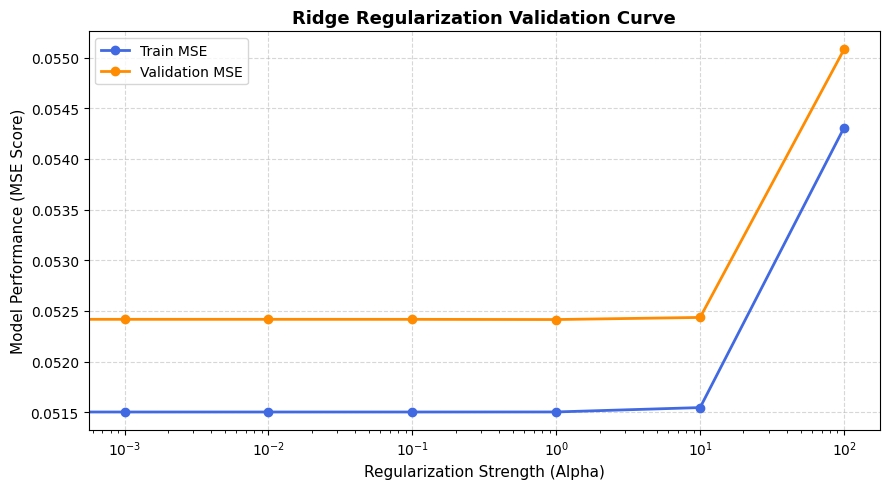

In [7]:
plt.figure(figsize=(9, 5))
plt.plot(alphas, alpha_train_r2s, label='Train MSE', color='royalblue', marker='o', linewidth=2)
plt.plot(alphas, alpha_val_r2s, label='Validation MSE', color='darkorange', marker='o', linewidth=2)

# Use log scale since alpha spans multiple orders of magnitude
plt.xscale('log')
plt.xlabel('Regularization Strength (Alpha)', fontsize=11)
plt.ylabel('Model Performance (MSE Score)', fontsize=11)
plt.title('Ridge Regularization Validation Curve', fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

No improvement. The baseline prevails.

In [8]:
# fit_intercept=True means "do include and calculate bias"
final_model = LinearRegression(fit_intercept=True)
final_model.fit(X_train, y_train)

print("Final Weights Vector via Scikit-Learn Solver:")
print(f"- Intercept (w0):       {final_model.intercept_:.8f}")
print(f"- Feature Slopes (w):   {final_model.coef_}\n")

Final Weights Vector via Scikit-Learn Solver:
- Intercept (w0):       15.31814373
- Feature Slopes (w):   [0.1823425  0.06333498 0.13414975]



In [9]:
test_preds_log = final_model.predict(X_test)
test_preds_usd = np.exp(test_preds_log) # invert target log
actual_test_prices_usd = np.exp(y_test.to_numpy())

test_mse_log = mean_squared_error(y_test.to_numpy(), test_preds_log)
test_mse_usd = mean_squared_error(actual_test_prices_usd, test_preds_usd)

test_rmse_log = np.sqrt(test_mse_log)
test_rmse_usd = np.sqrt(test_mse_usd)

test_r2 = r2_score(y_test.to_numpy(), test_preds_log)

print("\nFINAL TEST SET PERFORMANCE SUMMARY:")
print(f"- MSE:      {test_mse_log:.4f}")
print(f"- RMSE:     {test_rmse_log:.4f} (${test_rmse_usd:,.2f})")
print(f"- R2:       {test_r2:.4f}")

print("\nSample Holdout Comparisons (First 5 Houses):")

for i in range(5):
    diff = test_preds_usd[i] - actual_test_prices_usd[i]
    print(f"- House {i+1}: Pred: ${test_preds_usd[i]:,.2f} | Actual: ${actual_test_prices_usd[i]:,.2f} | Dev: ${diff:,.2f}")


FINAL TEST SET PERFORMANCE SUMMARY:
- MSE:      0.0650
- RMSE:     0.2550 ($1,337,835.15)
- R2:       0.4324

Sample Holdout Comparisons (First 5 Houses):
- House 1: Pred: $4,313,545.60 | Actual: $5,740,000.00 | Dev: $-1,426,454.40
- House 2: Pred: $4,695,440.21 | Actual: $6,629,000.00 | Dev: $-1,933,559.79
- House 3: Pred: $3,345,436.09 | Actual: $3,745,000.00 | Dev: $-399,563.91
- House 4: Pred: $4,392,984.40 | Actual: $5,810,000.00 | Dev: $-1,417,015.60
- House 5: Pred: $6,490,284.82 | Actual: $6,293,000.00 | Dev: $197,284.82


## Custom analytical solution

> As we know from the definition of derivatives, they measure the rate of change at a specific point. So, why can't we, as we did in analytical algebra, just use the very definition of derivative to find the desired minimum? We can!
>
> Based on the theory, we need to take the derivative and set it to $0$ for further analysis. Let's take MSE loss an an example, its derivative in matrix form:
> $$\nabla J(w) = \frac{1}{n}X^T(\hat y-y)$$
> Getting rid of the constant $n$:
> $$\frac{1}{n}X^T(\hat y-y)=0 /\cdot n $$
> Substitute for $\hat y$ (it is the predicted value so we just extend it with a linear-regression forward pass):
> $$X^T(\hat y-y)=0, \text{where} \underbrace{\hat y=Xw}_{\text{Out goal is to isolate $w$}}$$
> *Note*: We shouldn't forget that the *bias* in $\hat y$ was accounted for by adding a col of $1$ s to $X$. Then, we may multiply:
>$$\begin{gather}
X^T(Xw-y)=0 \\ \\
\text{expand brackets:} \\
X^TXw-X^Ty=0 \\ \\
\text{get rid of 0:} \\
X^TXw=X^Ty
\end{gather}$$
> Yes, we <u>would</u> want to divide by $X^T$ here to get rid of it on both sides, but *matrix division doesn't exist*. We can only multiply it by an inverted matrix $\frac{1}{(X^T)}$ to mimic the division. And we can write it as $\frac{1}{(X^T)}=(X^T)^{-1}$, which is an inverted matrix. 
> 
> However, *only square matrices are invertible*, which wouldn't make this formula universal as our input data is (almost) never square. Therefore, we let the math bend us this time. We willingly make our input matrix a square one! How? By <u>multiplying</u> both parts by $(X^TX)^{-1}$, essentially making it a division because:
> $$X^TXw \cdot (X^TX)^{-1}=\frac{X^TXw}{X^TX}=w \text{ (left part of the equation)}$$
> Whatever shapes they have (let's say `X.shape=(3,15)`, hence `(X^T).shape=(15,3)`, they will always converge to a square one (`3x3` in this case). Then:
>$$\begin{gather} 
X^TXw=X^Ty / \cdot (X^TX)^{-1} \\ 
w=(X^TX)^{-1}X^Ty 
\end{gather}$$
>
>The resulting equation is called **the Normal Equation**. This is our *analytical solution for linear regression*.

In [10]:
# ----- 1. Add the manual 1s column to the training feature matrix to properly multiply with bias -----
fake_ones_feature = np.ones((X_train.shape[0], 1))
X_train_vector = np.concatenate((fake_ones_feature, X_train.to_numpy()), axis=1)    # X_train.to_numpy() converts dataframe into np.array
y_train_vector = y_train.to_numpy().reshape(-1, 1)                                  # y_train.to_numpy() converts dataframe into np.array, then .reshape(-1,1) forces the shape of (n_rows, 1 column)

# 2. Compute using the Normal Equation
w_analytical = np.linalg.inv(X_train_vector.T @ X_train_vector) @ X_train_vector.T @ y_train_vector

print("PURE NUMPY ANALYTICAL SOLUTION MATRIX:")
print(w_analytical)

PURE NUMPY ANALYTICAL SOLUTION MATRIX:
[[15.31814373]
 [ 0.1823425 ]
 [ 0.06333498]
 [ 0.13414975]]


## Conclusion

|Train set scores|	test_MSE|	test_RMSE|	test_R2|
|----------------|----------|------------|---------|
|Baseline LR (sklearn)	|0.065|	0.255|	0.4324|
|Custom SGD LR|	0.0654|	0.2557|	0.4296|
|Final LR (sklearn)|	0.065|	0.255|	0.4324|

The baseline model persists. `R2` is noticeable worse on test than on train due to the limitation in data. The model explained less than half of the data variance. The sample size is also small. This model has done its best.

All 3 approaches: custom SGD, sklearn's LR and custom analytical solution has converged to the same scores.